In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("D:/Machine Learning datasets/Regression Models/insurance.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  13

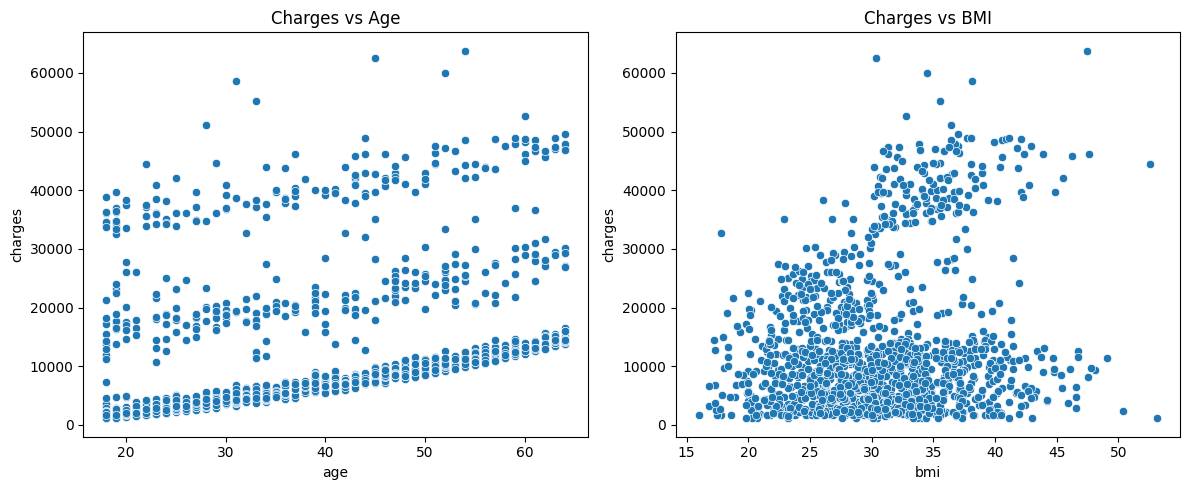

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df["age"], y=df["charges"])
plt.title("Charges vs Age")

plt.subplot(1,2,2)
sns.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("Charges vs BMI")

plt.tight_layout()
plt.show()


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [5]:
# Categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe())

                age           sex           bmi      children        smoker  \
count  1.070000e+03  1.070000e+03  1.070000e+03  1.070000e+03  1.070000e+03   
mean  -1.992176e-16 -6.308557e-17  3.104474e-16 -2.324205e-17  2.988264e-17   
std    1.000468e+00  1.000468e+00  1.000468e+00  1.000468e+00  1.000468e+00   
min   -1.518194e+00 -1.024602e+00 -2.428927e+00 -9.111921e-01 -5.087470e-01   
25%   -8.784157e-01 -1.024602e+00 -7.232890e-01 -9.111921e-01 -5.087470e-01   
50%    1.016470e-02  9.759891e-01 -5.651695e-02 -8.842793e-02 -5.087470e-01   
75%    8.276587e-01  9.759891e-01  6.570789e-01  7.343363e-01 -5.087470e-01   
max    1.751782e+00  9.759891e-01  2.787045e+00  3.202629e+00  1.965613e+00   

             region  
count  1.070000e+03  
mean  -5.312469e-17  
std    1.000468e+00  
min   -1.353256e+00  
25%   -4.561159e-01  
50%    4.410238e-01  
75%    4.410238e-01  
max    1.338164e+00  


In [10]:
models_processed = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

processed_results = []

for name, model in models_processed.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    processed_results.append([
        name,
        mean_absolute_error(y_test, preds),
        mean_squared_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ])

In [11]:
processed_df = pd.DataFrame(
    processed_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)
print(processed_df)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  3320.557035  2.348061e+07  4845.679237  0.783702
1      Decision Tree  2311.697076  3.120887e+07  5586.490072  0.712510
2      Random Forest  2125.687626  1.757037e+07  4191.703028  0.838145


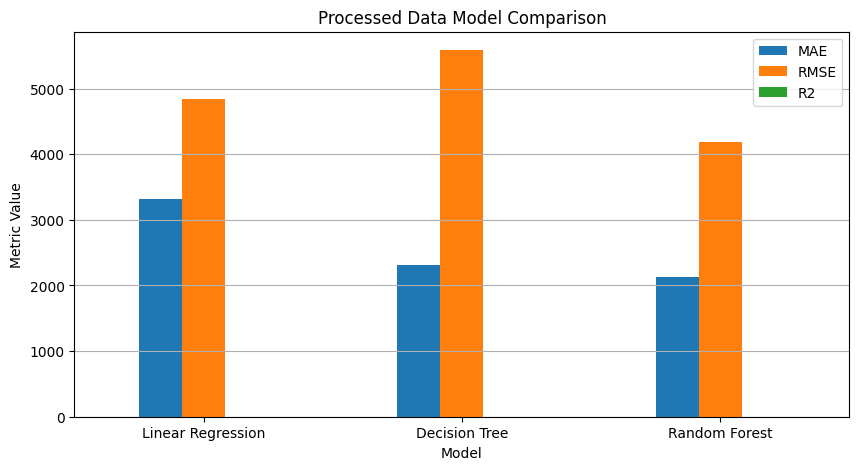

In [12]:
processed_df.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar", figsize=(10,5)
)
plt.title("Processed Data Model Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [13]:
for name, model in models_processed.items():
    train_r2 = model.score(X_train_scaled, y_train)
    test_r2 = model.score(X_test_scaled, y_test)
    print(f"{name} → Train R2: {train_r2:.3f}, Test R2: {test_r2:.3f}")

Linear Regression → Train R2: 0.738, Test R2: 0.784
Decision Tree → Train R2: 0.998, Test R2: 0.713
Random Forest → Train R2: 0.968, Test R2: 0.838


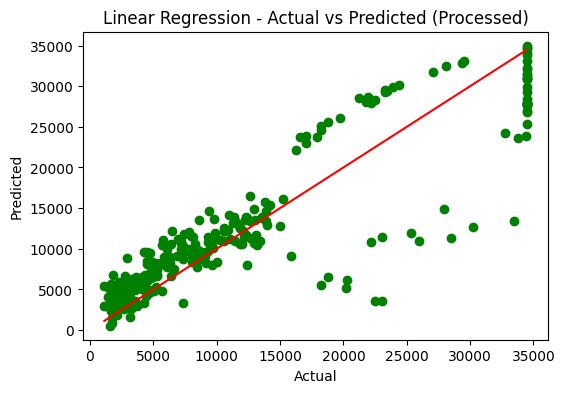

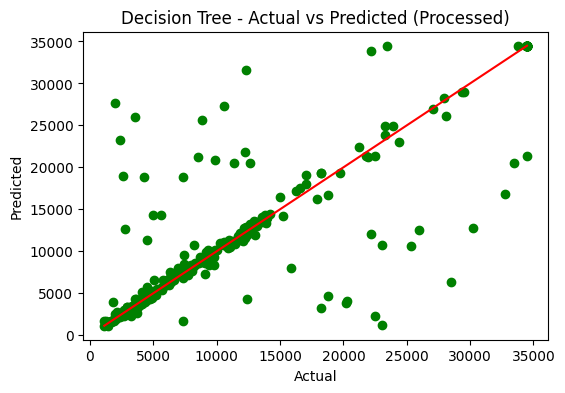

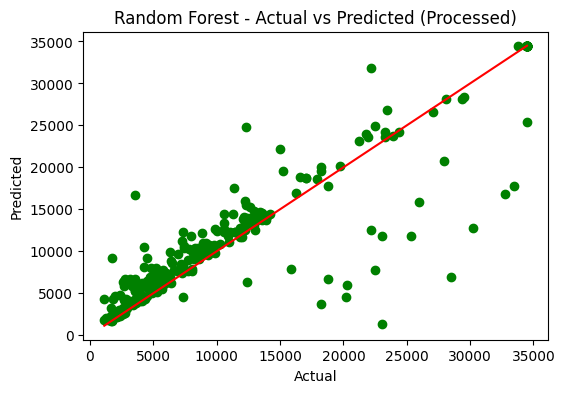

In [14]:
for name, model in models_processed.items():
    preds = model.predict(X_test_scaled)
    
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, preds, color="green")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red")
    plt.title(f"{name} - Actual vs Predicted (Processed)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [15]:
X_raw = X.copy()
y_raw = y.copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

In [16]:
models_raw = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

raw_results = []

for name, model in models_raw.items():
    model.fit(Xr_train, yr_train)
    preds = model.predict(Xr_test)
    
    raw_results.append([
        name,
        mean_absolute_error(yr_test, preds),
        mean_squared_error(yr_test, preds),
        np.sqrt(mean_squared_error(yr_test, preds)),
        r2_score(yr_test, preds)
    ])

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  3320.557035  2.348061e+07  4845.679237  0.783702
1      Decision Tree  2387.225771  3.284650e+07  5731.187015  0.697425
2      Random Forest  2145.644257  1.770285e+07  4207.475615  0.836925


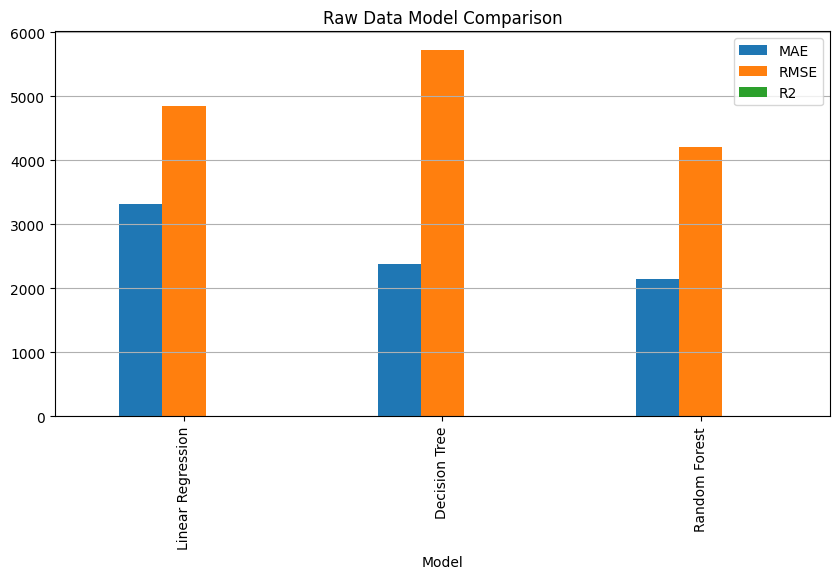

In [17]:
raw_df = pd.DataFrame(
    raw_results, columns=["Model","MAE","MSE","RMSE","R2"]
)
print(raw_df)

raw_df.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar", figsize=(10,5), title="Raw Data Model Comparison"
)
plt.grid(axis="y")
plt.show()

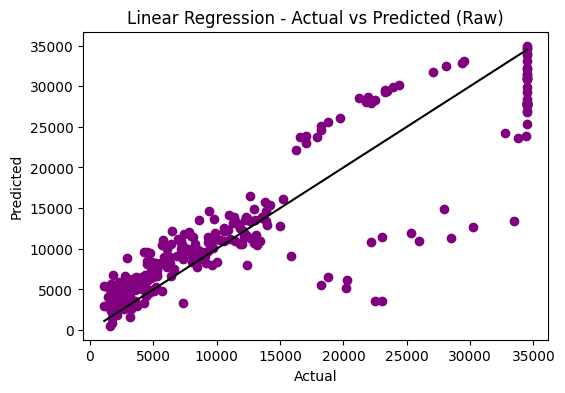

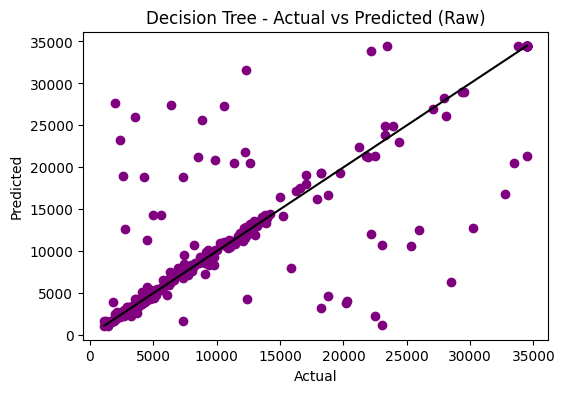

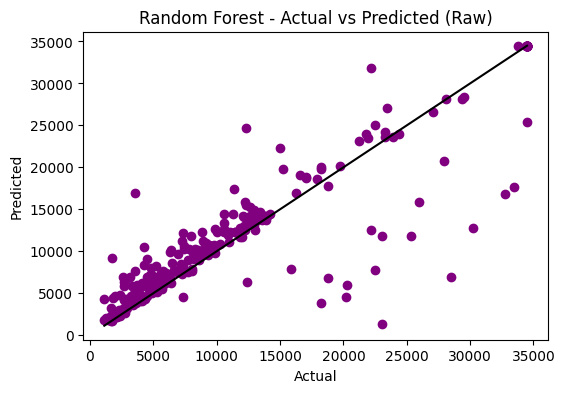

In [18]:
for name, model in models_raw.items():
    preds = model.predict(Xr_test)
    
    plt.figure(figsize=(6,4))
    plt.scatter(yr_test, preds, color="purple")
    plt.plot([yr_test.min(), yr_test.max()],
             [yr_test.min(), yr_test.max()],
             color="black")
    plt.title(f"{name} - Actual vs Predicted (Raw)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [19]:
joblib.dump(scaler, "insurance_scaler.pkl")

for name, model in models_processed.items():
    joblib.dump(model, f"{name.replace(' ','_')}_processed.pkl")

df.to_csv("processed_insurance_dataset.csv", index=False)